# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [95]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Training and evaluation on a single symbol

/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/2994793699.py:340: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dyn_thr_series = dyn_thr_series.fillna(method="ffill")
/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/2994793699.py:366: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["body_size_pct"] < self.body_size_pct_min, "label_pre"] = 0
/Users/carkod/binbot-notebooks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carkod/bin

[BullishFilter] label_pre reduced 1->1
[BodySizeFilter] label_pre reduced 1->1 using min body_size_pct=0.0075
[PreliminaryLabeling:AND] volume_cluster=26 | price_break=1 | pre_total=1
[PriceBreakDynamic] effective_recent_quantile~0.9160 threshold_med=0.0450
[AutoTunePriceBreak] target_rate=0.025 smoothing=0.6 lookback=200
[CurrentClassifier] Non-stratified split (minority too small).
{np.int64(0): np.float64(0.5010288065843621), np.int64(1): np.float64(243.5)}

=== CURRENT CLASSIFIER (Preliminary Label) ===
              precision    recall  f1-score   support

           0     1.0000    0.9918    0.9959       122
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9918       122
   macro avg     0.5000    0.4959    0.4979       122
weighted avg     1.0000    0.9918    0.9959       122

Top Feature Importances (top 10):
               feature  importance
10          momentum_3    0.135417
13       close_to_high    0.109572
12           range_pc

/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/2994793699.py:698: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df["_grp_first"] = df["timestamp"].dt.floor(freq)
/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/2994793699.py:702: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.index.min())
/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/2994793699.py:755: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df["_grp"] = df["timestamp"].dt.floor(freq)


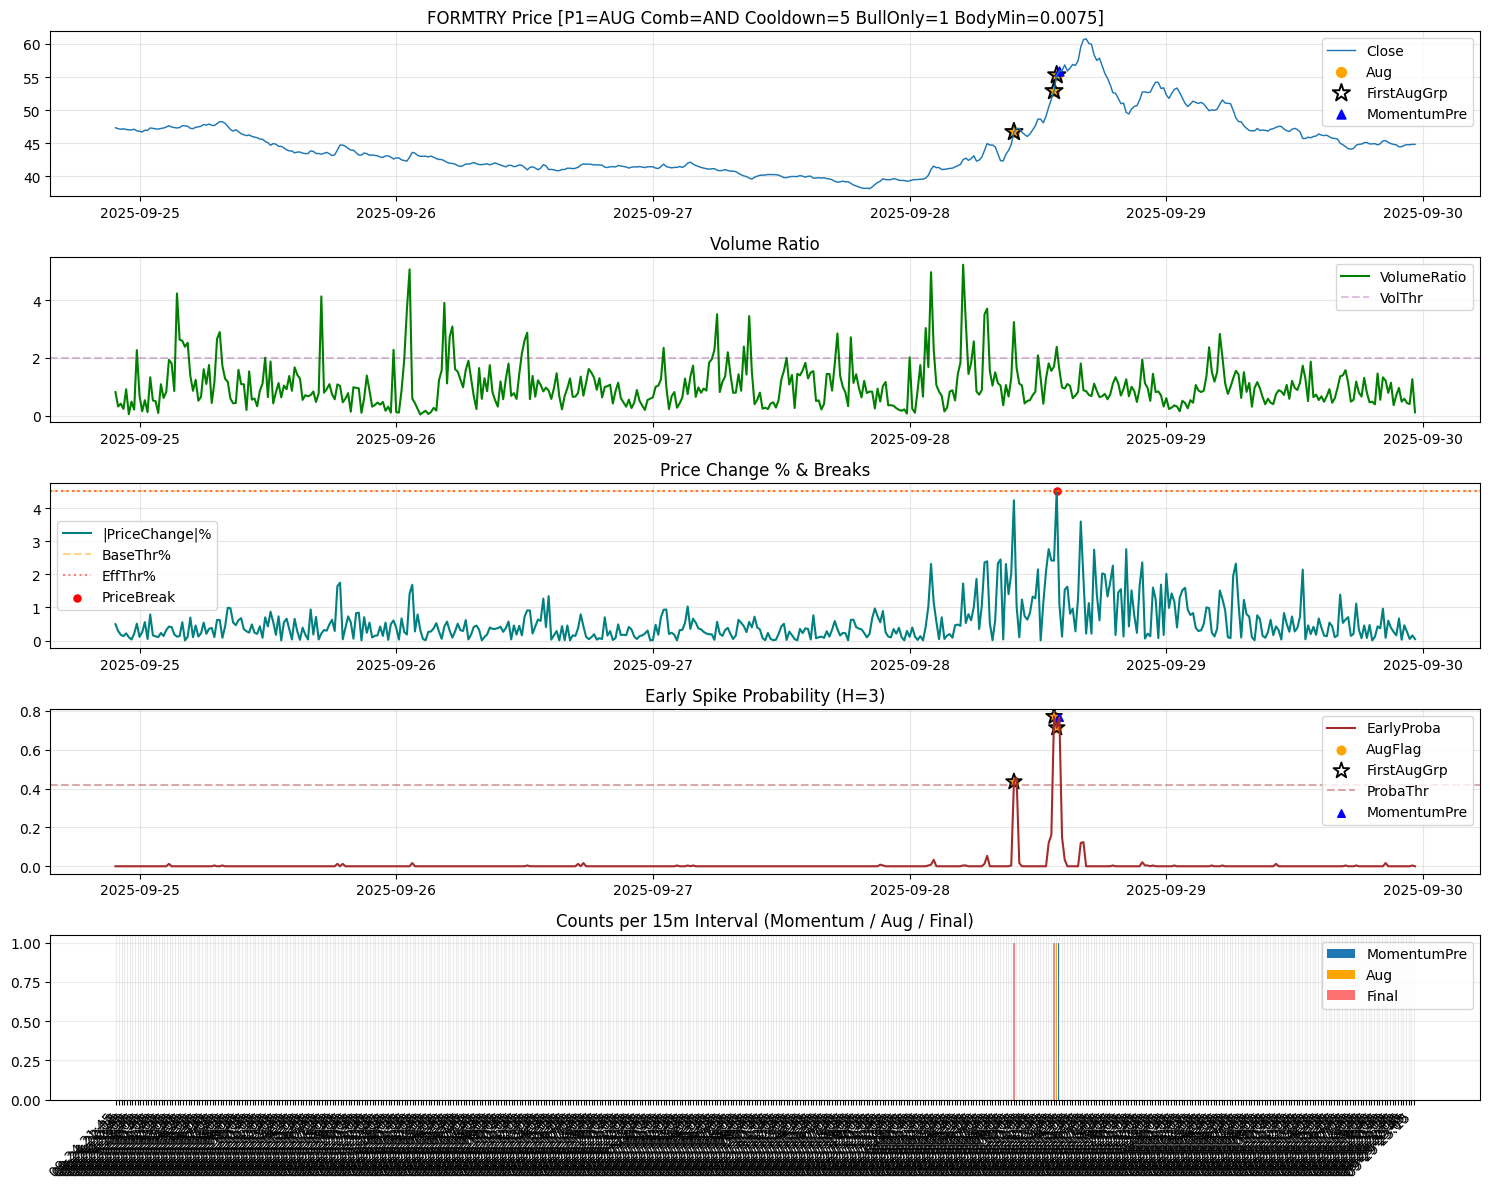

Momentum precursor precision (pre): 0.0
Momentum precursor precision (final): 0.0
Avg lead (final): None
=== Debug Signal Breakdown ===
rows: 487
volume_cluster_flag: 26
price_break_flag: 1
base_or_candidates: 26
base_and_candidates: 1
chosen_pattern_candidates: 1
after_bullish_filter: 1
after_body_size_filter: 1
final_label_count: 2
aug_flags: 3
suppressed_by_cooldown: 3
              timestamp  is_bullish  body_size_pct  momentum_precursor_flag  \
473 2025-09-29 20:00:00           1       0.001643                        0   
474 2025-09-29 20:15:00           1       0.010458                        0   
475 2025-09-29 20:30:00           1       0.006033                        0   
476 2025-09-29 20:45:00           0       0.003015                        0   
477 2025-09-29 21:00:00           0       0.005383                        0   
478 2025-09-29 21:15:00           0       0.005306                        0   
479 2025-09-29 21:30:00           0       0.004218                      

In [96]:
import pandas as pd
import numpy as np
import requests
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import joblib
import os

# ================= Core Constants / Defaults ================= #
ROLLING_WINDOW = 12
RSI_OVERSOLD = 30
MIN_PRICE_MOVE_FOR_ACTIVITY = 0.004  # (kept for possible future gating)
VOLUME_CONFIRM_THRESHOLD = 1.2       # (legacy reference)
FIXED_PRICE_THRESHOLD = 0.05         # 5% baseline absolute move

CHECKPOINT_DIR = "../checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ================= New Labeling Config Defaults ================= #
# 1. Volume Cluster Pattern
VOLUME_CLUSTER_MIN_RATIO = 2.2
VOLUME_CLUSTER_WINDOW = 8
VOLUME_CLUSTER_MIN_COUNT = 2
VOLUME_CLUSTER_LABEL_MODE = "last"

# 2. Price Break Pattern (Dynamic Quantile + Optional Auto Tuning)
PRICE_BREAK_BASE_THRESHOLD = 0.05
PRICE_BREAK_DYNAMIC_Q = 0.90
PRICE_BREAK_USE_DYNAMIC = True
# Adaptive auto-tune options (new)
PRICE_BREAK_AUTO_TUNE = False         # Enable adaptive quantile override
PRICE_BREAK_TARGET_RATE = 0.02        # Target fraction of bars flagged by price break pattern
PRICE_BREAK_MIN_QUANTILE = 0.75       # Lower bound for adaptive quantile (1 - target rate baseline)
PRICE_BREAK_MAX_QUANTILE = 0.985      # Upper bound for adaptive quantile
PRICE_BREAK_SMOOTHING = 0.50          # Blend weight between static dynamic_q and adaptive quantile
PRICE_BREAK_AUTO_LOOKBACK = 180       # Bars for adaptive quantile estimation window

# 3. Early Probability Augmentation Pattern
EARLY_PROBA_THRESHOLD = 0.45
EARLY_PROBA_SLOPE_LOOKBACK = 3
EARLY_PROBA_MIN_SLOPE = 0.05
EARLY_PROBA_REQUIRE_VOLUME = 1.2
EARLY_PROBA_AUGMENT = True

# 4. Cumulative Reset Interval
CUMULATIVE_RESET_MINUTES = 15

# 5. Combination logic
REQUIRE_BOTH_PATTERNS_DEFAULT = False

# 6. Momentum Precursor Detection (NEW)
MOMENTUM_PRECURSOR_ENABLE = True
MOMENTUM_HORIZON = 4
MOMENTUM_MIN_LEAD = 1
MOMENTUM_SCORE_QUANTILE = 0.92
MOMENTUM_REQUIRE_NO_CURRENT_LABEL = True

# 7. Post Spike Cooldown (NEW)
POST_SPIKE_COOLDOWN_BARS = 0

# 8. Require bullish bar for spike emission (NEW)
REQUIRE_BULLISH_SPIKE_DEFAULT = True

# 9. Minimum candle body size percentage (NEW)
BODY_SIZE_PCT_MIN_DEFAULT = 0.008

@dataclass
class TrainingArtifacts:
    df: pd.DataFrame
    clf: Optional[RandomForestClassifier] = None
    early_clf: Optional[RandomForestClassifier] = None
    magnitude_reg: Optional[RandomForestRegressor] = None
    feature_list_current: List[str] = field(default_factory=list)
    early_feature_list: List[str] = field(default_factory=list)
    current_feature_importances: Optional[pd.DataFrame] = None
    early_feature_importances: Optional[pd.DataFrame] = None
    metadata: dict = field(default_factory=dict)


class SpikeHunterV2:
    """Refactored Spike Hunter V2 + Momentum + Adaptive Quantile.

    New in this update:
      - Adaptive auto-tune of price break dynamic quantile aiming for a target flag rate.
      - Debug signal breakdown (previous addition).
    """

    BASE_FEATURES = [
        "price_change", "price_change_abs", "body_size_pct", "upper_wick_ratio", "lower_wick_ratio",
        "is_bullish", "close_open_ratio", "price_zscore", "volume_ratio", "volume_zscore",
        "momentum_3", "momentum_5", "range_pct", "close_to_high", "close_to_low", "taker_base",
        "taker_quote", "taker_buy_ratio", "quote_asset_volume", "number_of_trades", "trades_ratio",
        "trades_zscore", "quote_volume_ratio",
    ]

    EARLY_FEATURES = [
        "std_ratio_8_20", "vol_ratio_slope_3", "vol_ratio_accel", "trades_ratio_slope_3",
        "quote_vol_ratio_slope_3", "pc_1", "pc_2c", "pc_3c", "pc_pos_count_5", "pc_abs_sum_5",
        "taker_buy_ratio", "taker_buy_ratio_slope_5", "body_size_pct_z", "vol_compression_flag",
        "volume_ratio", "price_zscore",
    ]

    def __init__(
        self,
        symbol: str = "SNXBTC",
        early_horizon: int = 3,
        dynamic_quantile: float = 0.94,  # legacy param retained for compatibility (maps to price_break_dynamic_q)
        current_spike_proba_threshold: float = 0.30,
        volume_cluster_min_ratio: float = VOLUME_CLUSTER_MIN_RATIO,
        volume_cluster_window: int = VOLUME_CLUSTER_WINDOW,
        volume_cluster_min_count: int = VOLUME_CLUSTER_MIN_COUNT,
        volume_cluster_label_mode: str = VOLUME_CLUSTER_LABEL_MODE,
        price_break_base_threshold: float = PRICE_BREAK_BASE_THRESHOLD,
        price_break_dynamic_q: float = PRICE_BREAK_DYNAMIC_Q,
        price_break_use_dynamic: bool = PRICE_BREAK_USE_DYNAMIC,
        # Adaptive options
        price_break_auto_tune: bool = PRICE_BREAK_AUTO_TUNE,
        price_break_target_rate: float = PRICE_BREAK_TARGET_RATE,
        price_break_min_quantile: float = PRICE_BREAK_MIN_QUANTILE,
        price_break_max_quantile: float = PRICE_BREAK_MAX_QUANTILE,
        price_break_smoothing: float = PRICE_BREAK_SMOOTHING,
        price_break_auto_lookback: int = PRICE_BREAK_AUTO_LOOKBACK,
        early_proba_threshold: float = EARLY_PROBA_THRESHOLD,
        early_proba_slope_lookback: int = EARLY_PROBA_SLOPE_LOOKBACK,
        early_proba_min_slope: float = EARLY_PROBA_MIN_SLOPE,
        early_proba_require_volume: float = EARLY_PROBA_REQUIRE_VOLUME,
        early_proba_augment: bool = EARLY_PROBA_AUGMENT,
        require_both_patterns: bool = REQUIRE_BOTH_PATTERNS_DEFAULT,
        cumulative_reset_minutes: Optional[int] = CUMULATIVE_RESET_MINUTES,
        # Momentum precursor config
        momentum_precursor_enable: bool = MOMENTUM_PRECURSOR_ENABLE,
        momentum_horizon: int = MOMENTUM_HORIZON,
        momentum_min_lead: int = MOMENTUM_MIN_LEAD,
        momentum_score_quantile: float = MOMENTUM_SCORE_QUANTILE,
        momentum_require_no_current_label: bool = MOMENTUM_REQUIRE_NO_CURRENT_LABEL,
        # Cooldown config
        post_spike_cooldown_bars: int = POST_SPIKE_COOLDOWN_BARS,
        # Bullish-only config
        require_bullish_spike: bool = REQUIRE_BULLISH_SPIKE_DEFAULT,
        # Body size minimum
        body_size_pct_min: float = BODY_SIZE_PCT_MIN_DEFAULT,
    ):
        self.symbol = symbol
        self.early_horizon = early_horizon
        self.dynamic_quantile = dynamic_quantile  # retained but unused directly; mapped to price_break_dynamic_q
        self.current_spike_proba_threshold = current_spike_proba_threshold
        self.volume_cluster_min_ratio = volume_cluster_min_ratio
        self.volume_cluster_window = volume_cluster_window
        self.volume_cluster_min_count = volume_cluster_min_count
        self.volume_cluster_label_mode = volume_cluster_label_mode.lower()
        self.price_break_base_threshold = price_break_base_threshold
        self.price_break_dynamic_q = price_break_dynamic_q
        self.price_break_use_dynamic = price_break_use_dynamic
        # Adaptive
        self.price_break_auto_tune = price_break_auto_tune
        self.price_break_target_rate = price_break_target_rate
        self.price_break_min_quantile = price_break_min_quantile
        self.price_break_max_quantile = price_break_max_quantile
        self.price_break_smoothing = price_break_smoothing
        self.price_break_auto_lookback = price_break_auto_lookback
        self.early_proba_threshold = early_proba_threshold
        self.early_proba_slope_lookback = early_proba_slope_lookback
        self.early_proba_min_slope = early_proba_min_slope
        self.early_proba_require_volume = early_proba_require_volume
        self.early_proba_augment = early_proba_augment
        self.require_both_patterns = require_both_patterns
        self.cumulative_reset_minutes = cumulative_reset_minutes
        # Momentum precursor
        self.momentum_precursor_enable = momentum_precursor_enable
        self.momentum_horizon = momentum_horizon
        self.momentum_min_lead = momentum_min_lead
        self.momentum_score_quantile = momentum_score_quantile
        self.momentum_require_no_current_label = momentum_require_no_current_label
        # Cooldown
        self.post_spike_cooldown_bars = max(0, post_spike_cooldown_bars)
        # Bullish-only flag
        self.require_bullish_spike = require_bullish_spike
        # Body size threshold
        self.body_size_pct_min = max(0.0, body_size_pct_min)

        self.artifacts: Optional[TrainingArtifacts] = None
        self._current_fi: Optional[pd.DataFrame] = None
        self._early_fi: Optional[pd.DataFrame] = None
        self._effective_price_break_threshold = None
        self._effective_price_break_quantile = None

        self.df = self.fetch_binance_klines(self.symbol, interval="15m", limit=500)
        self.base_features()
        self.preliminary_labeling()

    @staticmethod
    def apply_heikin_ashi(df: pd.DataFrame) -> pd.DataFrame:
        """
        Exact same function as Binquant project
        keep as is
        """

        if df.empty:
            return df

        required_columns = {"open", "high", "low", "close"}
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"Missing required columns for Heikin Ashi: {missing}")

        # Work on a copy & ensure chronological order if timestamp provided.
        if "timestamp" in df.columns:
            work = df.sort_values("timestamp").reset_index(drop=True).copy()
        else:
            work = df.reset_index(drop=True).copy()

        # Compute HA_Close from ORIGINAL OHLC (still intact in 'work').
        ha_close = (work["open"] + work["high"] + work["low"] + work["close"]) / 4.0

        # Seed HA_Open with original O & C (not HA close).
        ha_open = ha_close.copy()
        ha_open.iloc[0] = (work["open"].iloc[0] + work["close"].iloc[0]) / 2.0
        for i in range(1, len(work)):
            ha_open.iloc[i] = (ha_open.iloc[i - 1] + ha_close.iloc[i - 1]) / 2.0

        # High / Low derived from max/min of (raw high/low, ha_open, ha_close)
        ha_high = pd.concat([work["high"], ha_open, ha_close], axis=1).max(axis=1)
        ha_low = pd.concat([work["low"], ha_open, ha_close], axis=1).min(axis=1)

        # Assign transformed values.
        work.loc[:, "open"] = ha_open
        work.loc[:, "high"] = ha_high
        work.loc[:, "low"] = ha_low
        work.loc[:, "close"] = ha_close

        return work

    # ---------------- Data Fetch & Base Feature Engineering ---------------- #
    def fetch_binance_klines(self, symbol: str, interval: str = "15m", limit: int = 500, end_time: Optional[int] = None) -> pd.DataFrame:
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol, "interval": interval, "limit": limit}
        if end_time:
            params["endTime"] = end_time
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        df = pd.DataFrame(data, columns=[
            "open_time","open","high","low","close","volume","close_time","quote_asset_volume",
            "number_of_trades","taker_base","taker_quote","ignore"
        ])
        num_cols = ["open","high","low","close","volume","quote_asset_volume","number_of_trades","taker_base","taker_quote"]
        df[num_cols] = df[num_cols].astype(float)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df = df[["timestamp","open","high","low","close","volume","quote_asset_volume","taker_base","taker_quote","number_of_trades"]].sort_values("timestamp").reset_index(drop=True)
        heikin_ashi_df = self.apply_heikin_ashi(df)
        return heikin_ashi_df

    def base_features(self, window: int = ROLLING_WINDOW):
        df = self.df.copy().sort_values("timestamp").reset_index(drop=True)
        eff = window
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close","open"]].max(axis=1)
        df["lower_wick"] = df[["close","open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (df["volume"].rolling(eff).std() + 1e-6)
        if "quote_asset_volume" in df.columns:
            df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
            df["quote_volume_ratio"] = df["quote_asset_volume"] / (df["quote_volume_ma"] + 1e-6)
        else:
            df["quote_volume_ma"] = 0.0
            df["quote_volume_ratio"] = 0.0
        if "number_of_trades" in df.columns:
            df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
            df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
            df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (df["number_of_trades"].rolling(eff).std() + 1e-6)
        else:
            df["trades_ma"] = 0.0
            df["trades_ratio"] = 0.0
            df["trades_zscore"] = 0.0
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"] + 1e-6) / (df["close"] + 1e-6)
        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0
        delta = df["close"].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-6)
        df["rsi"] = 100 - (100 / (1 + rs))
        self.df = df

    # ---------------- New Labeling Components ---------------- #
    def compute_volume_cluster_flag(self, df: pd.DataFrame) -> pd.Series:
        cond = df["volume_ratio"] >= self.volume_cluster_min_ratio
        rolling_count = cond.rolling(self.volume_cluster_window, min_periods=1).sum()
        flag = (rolling_count >= self.volume_cluster_min_count) & cond
        if self.volume_cluster_label_mode == "last":
            flag_shift = flag.shift(-1).fillna(False)
            flag = flag & (~flag_shift)
        return flag.astype(int)

    def compute_price_break_flag(self, df: pd.DataFrame) -> Tuple[pd.Series, float]:
        dyn_thr_series = None
        used_quantile = None
        if self.price_break_use_dynamic:
            # Base dynamic series with configured quantile
            base_dyn = df["price_change_abs"].rolling(60, min_periods=20).quantile(self.price_break_dynamic_q)
            dyn_thr_series = base_dyn
            used_quantile = self.price_break_dynamic_q
            if self.price_break_auto_tune:
                # Compute adaptive quantile (q_recent) = 1 - target_rate clipped to min/max
                q_recent = 1.0 - self.price_break_target_rate
                q_recent = np.clip(q_recent, self.price_break_min_quantile, self.price_break_max_quantile)
                # Rolling adaptive quantile over larger lookback to reflect recent volatility distribution
                adaptive_series = df["price_change_abs"].rolling(self.price_break_auto_lookback, min_periods=40).apply(
                    lambda x: np.quantile(x, q_recent), raw=False
                )
                # Smooth between configured base dynamic and adaptive
                dyn_thr_series = (
                    self.price_break_smoothing * base_dyn + (1 - self.price_break_smoothing) * adaptive_series
                )
                used_quantile = self.price_break_smoothing * self.price_break_dynamic_q + (1 - self.price_break_smoothing) * q_recent
        if dyn_thr_series is not None:
            dyn_thr_series = dyn_thr_series.fillna(method="ffill")
            thr_series = pd.Series(np.maximum(self.price_break_base_threshold, dyn_thr_series), index=df.index)
        else:
            thr_series = pd.Series(self.price_break_base_threshold, index=df.index)
            used_quantile = None
        price_break_flag = (df["price_change_abs"] >= thr_series).astype(int)
        effective_thr = float(thr_series.tail(50).median()) if len(thr_series) > 0 else self.price_break_base_threshold
        self._effective_price_break_quantile = used_quantile
        return price_break_flag, effective_thr

    def preliminary_labeling(self):
        df = self.df.copy().dropna().reset_index(drop=True)
        df["volume_cluster_flag"] = self.compute_volume_cluster_flag(df)
        price_break_flag, eff_thr = self.compute_price_break_flag(df)
        df["price_break_flag"] = price_break_flag
        if self.require_both_patterns:
            df["label_pre"] = ((df["volume_cluster_flag"] == 1) & (df["price_break_flag"] == 1)).astype(int)
        else:
            df["label_pre"] = ((df["volume_cluster_flag"] == 1) | (df["price_break_flag"] == 1)).astype(int)
        if self.require_bullish_spike:
            before_bull = df["label_pre"].sum()
            df["label_pre"] = (df["label_pre"] == 1) & (df["is_bullish"] == 1)
            after_bull = df["label_pre"].sum()
            print(f"[BullishFilter] label_pre reduced {before_bull}->{after_bull}")
        if self.body_size_pct_min > 0:
            before_bs = df["label_pre"].sum()
            df.loc[df["body_size_pct"] < self.body_size_pct_min, "label_pre"] = 0
            after_bs = df["label_pre"].sum()
            print(f"[BodySizeFilter] label_pre reduced {before_bs}->{after_bs} using min body_size_pct={self.body_size_pct_min:.4f}")
        df["label_pre"] = df["label_pre"].astype(int)
        df["label"] = df["label_pre"].copy()
        self._effective_price_break_threshold = eff_thr
        self.df = df
        mode = "AND" if self.require_both_patterns else "OR"
        print(f"[PreliminaryLabeling:{mode}] volume_cluster={df['volume_cluster_flag'].sum()} | price_break={df['price_break_flag'].sum()} | pre_total={df['label_pre'].sum()}")
        if self.price_break_use_dynamic and self._effective_price_break_quantile is not None:
            print(f"[PriceBreakDynamic] effective_recent_quantile~{self._effective_price_break_quantile:.4f} threshold_med={self._effective_price_break_threshold:.4f}")
        if self.price_break_auto_tune:
            print(f"[AutoTunePriceBreak] target_rate={self.price_break_target_rate} smoothing={self.price_break_smoothing} lookback={self.price_break_auto_lookback}")

    # ---------------- Early Feature Construction ---------------- #
    def build_early_features(self, label_col: str = "label_pre"):
        df = self.df
        future_any = df[label_col].shift(-1).rolling(self.early_horizon).max()
        df["lead_spike_label"] = future_any.fillna(0).astype(int)
        df["future_spike_magnitude"] = df["price_change_abs"].shift(-1).rolling(self.early_horizon).max()
        df["rolling_price_std_8"] = df["close"].rolling(8).std()
        df["rolling_price_std_20"] = df["close"].rolling(20).std()
        df["std_ratio_8_20"] = df["rolling_price_std_8"] / (df["rolling_price_std_20"] + 1e-6)
        df["vol_ratio_slope_3"] = df["volume_ratio"].diff(3)
        df["vol_ratio_accel"] = df["vol_ratio_slope_3"].diff()
        df["trades_ratio_slope_3"] = df.get("trades_ratio", 0).diff(3)
        df["quote_vol_ratio_slope_3"] = df.get("quote_volume_ratio", 0).diff(3)
        df["pc_1"] = df["price_change"]
        df["pc_2c"] = df["price_change"].rolling(2).sum()
        df["pc_3c"] = df["price_change"].rolling(3).sum()
        df["pc_pos_count_5"] = (df["price_change"] > 0).rolling(5).sum()
        df["pc_abs_sum_5"] = df["price_change_abs"].rolling(5).sum()
        df["taker_buy_ratio"] = df.get("taker_buy_ratio", 0.0)
        df["taker_buy_ratio_slope_5"] = df["taker_buy_ratio"].diff(5)
        df["body_size_pct_ma_10"] = df["body_size_pct"].rolling(10).mean()
        df["body_size_pct_std_10"] = df["body_size_pct"].rolling(10).std()
        df["body_size_pct_z"] = (df["body_size_pct"] - df["body_size_pct_ma_10"]) / (df["body_size_pct_std_10"] + 1e-6)
        df["vol_compression_flag"] = (df["rolling_price_std_8"] < df["rolling_price_std_20"] * 0.6).astype(int)
        self.df = df

    # ---------------- Momentum Precursor ---------------- #
    def compute_momentum_precursor(self, use_label: str = "label_pre"):
        if not self.momentum_precursor_enable:
            self.df["momentum_precursor_flag"] = 0
            return
        df = self.df
        if "body_size_pct_z" not in df.columns:
            self.build_early_features(label_col=use_label)
        future_spike = df[use_label].shift(-1).rolling(self.momentum_horizon).max().fillna(0).astype(int)
        precursor_candidate = future_spike.eq(1)
        if self.momentum_require_no_current_label:
            precursor_candidate &= (df[use_label] == 0)
        lead_mask = df[use_label].shift(-self.momentum_min_lead).rolling(self.momentum_min_lead).max().fillna(0) == 0
        precursor_candidate &= lead_mask
        vol_slope = df["volume_ratio"].diff(2)
        price_cum3 = df["price_change"].rolling(3).sum()
        body_z = df.get("body_size_pct_z", 0)
        trades_slope = df.get("trades_ratio", 0).diff(3)
        compression_release = (df.get("vol_compression_flag", 0) == 1) & (df["volume_ratio"] > 1.15)
        def zseries(s):
            return (s - s.mean()) / (s.std() + 1e-6)
        score = (
            0.30 * zseries(vol_slope.fillna(0)) +
            0.25 * zseries(price_cum3.fillna(0)) +
            0.20 * zseries(body_z.fillna(0)) +
            0.15 * zseries(trades_slope.fillna(0)) +
            0.10 * compression_release.astype(float)
        )
        df["momentum_precursor_score"] = score
        candidate_scores = score[precursor_candidate]
        if candidate_scores.empty:
            df["momentum_precursor_flag"] = 0
        else:
            thr = candidate_scores.quantile(self.momentum_score_quantile)
            df["momentum_precursor_flag"] = ((score >= thr) & precursor_candidate).astype(int)
            print(f"[MomentumPrecursor] threshold={thr:.4f} candidates={int(precursor_candidate.sum())} flagged={int(df['momentum_precursor_flag'].sum())}")
        self.df = df

    def evaluate_momentum_precursor(self, horizon: Optional[int] = None, pre_label_col: str = "label_pre", final_label_col: str = "label") -> dict:
        if "momentum_precursor_flag" not in self.df.columns:
            return {}
        h = horizon or self.momentum_horizon
        df = self.df.reset_index(drop=True)
        pre_flags = df["momentum_precursor_flag"].values
        pre_idxs = np.where(pre_flags == 1)[0]
        pre_label = df[pre_label_col].values
        final_label = df[final_label_col].values
        total_precursors = len(pre_idxs)
        if total_precursors == 0:
            metrics = {"momentum_precursor_count": 0, "momentum_precursor_precision_pre": None, "momentum_precursor_precision_final": None}
            return metrics
        lead_hits_pre = 0
        lead_hits_final = 0
        lead_times_pre = []
        lead_times_final = []
        for i in pre_idxs:
            window_end = min(i + h, len(df) - 1)
            future_range = slice(i + 1, window_end + 1)
            if pre_label[future_range].max() == 1:
                lead_hits_pre += 1
                future_idxs = np.where(pre_label[i+1:window_end+1] == 1)[0]
                if future_idxs.size > 0:
                    lead_times_pre.append(int(future_idxs[0] + 1))
            if final_label[future_range].max() == 1:
                lead_hits_final += 1
                future_idxs_f = np.where(final_label[i+1:window_end+1] == 1)[0]
                if future_idxs_f.size > 0:
                    lead_times_final.append(int(future_idxs_f[0] + 1))
        precision_pre = lead_hits_pre / total_precursors if total_precursors else None
        precision_final = lead_hits_final / total_precursors if total_precursors else None
        avg_lead_pre = float(np.mean(lead_times_pre)) if lead_times_pre else None
        median_lead_pre = float(np.median(lead_times_pre)) if lead_times_pre else None
        avg_lead_final = float(np.mean(lead_times_final)) if lead_times_final else None
        median_lead_final = float(np.median(lead_times_final)) if lead_times_final else None
        metrics = {
            "momentum_precursor_count": int(total_precursors),
            "momentum_precursor_precision_pre": precision_pre,
            "momentum_precursor_precision_final": precision_final,
            "momentum_precursor_avg_lead_pre": avg_lead_pre,
            "momentum_precursor_median_lead_pre": median_lead_pre,
            "momentum_precursor_avg_lead_final": avg_lead_final,
            "momentum_precursor_median_lead_final": median_lead_final,
            "momentum_precursor_horizon": h,
        }
        print("=== Momentum Precursor Metrics ===")
        for k, v in metrics.items():
            print(f"{k}: {v}")
        return metrics

    # ---------------- Diagnostics ---------------- #
    def debug_signal_breakdown(self) -> dict:
        if not {"volume_cluster_flag", "price_break_flag", "label_pre"}.issubset(self.df.columns):
            print("[Debug] Required columns missing; run preliminary_labeling first.")
            return {}
        df = self.df.copy()
        base_or = ((df["volume_cluster_flag"] == 1) | (df["price_break_flag"] == 1)).astype(int)
        base_and = ((df["volume_cluster_flag"] == 1) & (df["price_break_flag"] == 1)).astype(int)
        chosen = base_and if self.require_both_patterns else base_or
        after_bull = chosen if not self.require_bullish_spike else (chosen & (df["is_bullish"] == 1)).astype(int)
        after_body = after_bull if self.body_size_pct_min <= 0 else (after_bull & (df["body_size_pct"] >= self.body_size_pct_min)).astype(int)
        cooldown_final_labels = df.get("label", pd.Series(0, index=df.index)).astype(int)
        suppressed = df.get("suppressed_label", pd.Series(0, index=df.index)).sum()
        aug_added = int(df.get("early_proba_aug_flag", pd.Series(0, index=df.index)).sum())
        out = {
            "rows": len(df),
            "volume_cluster_flag": int(df["volume_cluster_flag"].sum()),
            "price_break_flag": int(df["price_break_flag"].sum()),
            "base_or_candidates": int(base_or.sum()),
            "base_and_candidates": int(base_and.sum()),
            "chosen_pattern_candidates": int(chosen.sum()),
            "after_bullish_filter": int(after_bull.sum()),
            "after_body_size_filter": int(after_body.sum()),
            "final_label_count": int(cooldown_final_labels.sum()),
            "aug_flags": aug_added,
            "suppressed_by_cooldown": int(suppressed),
            "config": {
                "require_both_patterns": self.require_both_patterns,
                "require_bullish_spike": self.require_bullish_spike,
                "body_size_pct_min": self.body_size_pct_min,
                "post_spike_cooldown_bars": self.post_spike_cooldown_bars,
                "early_proba_threshold": self.early_proba_threshold,
                "volume_cluster_min_ratio": self.volume_cluster_min_ratio,
                "price_break_base_threshold": self.price_break_base_threshold,
                "price_break_dynamic_q": self.price_break_dynamic_q,
                "price_break_auto_tune": self.price_break_auto_tune,
                "effective_price_break_quantile": self._effective_price_break_quantile,
            }
        }
        print("=== Debug Signal Breakdown ===")
        for k, v in out.items():
            if k != "config":
                print(f"{k}: {v}")
        return out

    # ---------------- Model Training ---------------- #
    def train_current_classifier(self) -> Tuple[Optional[RandomForestClassifier], List[str]]:
        df = self.df
        feature_list = [c for c in self.BASE_FEATURES if c in df.columns]
        y = df["label_pre"].astype(int)
        if y.sum() == 0 or len(np.unique(y)) < 2:
            print("[CurrentClassifier] Skipped (insufficient positives or class variety).")
            return None, feature_list
        X = df[feature_list]
        class_counts = np.bincount(y)
        min_class_count = class_counts.min() if len(class_counts) > 1 else class_counts[0]
        stratify_opt = y if (min_class_count >= 2 and len(np.unique(y)) > 1) else None
        if stratify_opt is None:
            print("[CurrentClassifier] Non-stratified split (minority too small).")
        class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
        print({cls: w for cls, w in zip(np.unique(y), class_weights)})
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=stratify_opt, test_size=0.25, random_state=42)
        clf = RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_split=4, min_samples_leaf=2, class_weight="balanced", random_state=42
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        try:
            proba = clf.predict_proba(X_test)
            if proba.shape[1] == 2:
                pos_col = list(clf.classes_).index(1)
                y_proba = proba[:, pos_col]
            else:
                only_class = clf.classes_[0]
                y_proba = np.ones(len(X_test)) if only_class == 1 else np.zeros(len(X_test))
        except Exception:
            y_proba = np.zeros(len(X_test))
        print("\n=== CURRENT CLASSIFIER (Preliminary Label) ===")
        print(classification_report(y_test, y_pred, digits=4))
        if len(np.unique(y_test)) == 2:
            try:
                print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
            except Exception:
                pass
        fi = pd.DataFrame({"feature": feature_list, "importance": clf.feature_importances_}).sort_values("importance", ascending=False)
        self._current_fi = fi.reset_index(drop=True)
        print("Top Feature Importances (top 10):")
        print(fi.head(10))
        return clf, feature_list

    def train_early_classifier_and_regressor(self) -> Tuple[Optional[RandomForestClassifier], Optional[RandomForestRegressor], List[str]]:
        self.build_early_features(label_col="label_pre")
        df = self.df
        if not self.early_proba_augment:
            print("[EarlyClassifier] Augmentation disabled -> skipping early model training.")
            return None, None, self.EARLY_FEATURES
        early_df = df.dropna(subset=self.EARLY_FEATURES + ["lead_spike_label"]).copy()
        if early_df.empty:
            print("[EarlyClassifier] No rows after NA drop.")
            return None, None, self.EARLY_FEATURES
        lead_y = early_df["lead_spike_label"].astype(int)
        pos = int(lead_y.sum())
        total = len(lead_y)
        print(f"[EarlyClassifier] lead_spike_label positives={pos} of {total}")
        if pos < 3:
            print("[EarlyClassifier] Too few positives; skipping.")
            return None, None, self.EARLY_FEATURES
        Xc = early_df[self.EARLY_FEATURES].fillna(0)
        class_counts = np.bincount(lead_y)
        min_class_count = class_counts.min() if len(class_counts) > 1 else class_counts[0]
        stratify_opt = lead_y if (min_class_count >= 2 and len(np.unique(lead_y)) > 1) else None
        if stratify_opt is None:
            print("[EarlyClassifier] Non-stratified split (minority too small).")
        _ = compute_class_weight("balanced", classes=np.unique(lead_y), y=lead_y)
        Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, lead_y, stratify=stratify_opt, test_size=0.30, random_state=42)
        early_clf = RandomForestClassifier(
            n_estimators=240, max_depth=10, min_samples_split=4, min_samples_leaf=2, class_weight="balanced", random_state=42
        )
        early_clf.fit(Xc_train, yc_train)
        yc_pred = early_clf.predict(Xc_test)
        try:
            eproba = early_clf.predict_proba(Xc_test)
            if eproba.shape[1] == 2:
                pos_col = list(early_clf.classes_).index(1)
                yc_proba = eproba[:, pos_col]
            else:
                only_class = early_clf.classes_[0]
                yc_proba = np.ones(len(Xc_test)) if only_class == 1 else np.zeros(len(Xc_test))
        except Exception:
            yc_proba = np.zeros(len(Xc_test))
        print(f"=== EARLY LEAD CLASSIFIER (H={self.early_horizon}) ===")
        print(classification_report(yc_test, yc_pred, digits=4))
        if len(np.unique(yc_test)) == 2:
            try:
                print(f"Early ROC AUC: {roc_auc_score(yc_test, yc_proba):.4f}")
            except Exception:
                pass
        early_fi = pd.DataFrame({"feature": self.EARLY_FEATURES, "importance": early_clf.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
        self._early_fi = early_fi
        mag_df = early_df[early_df["lead_spike_label"] == 1]
        reg = None
        if mag_df["future_spike_magnitude"].notna().sum() >= 6:
            reg = RandomForestRegressor(
                n_estimators=140, max_depth=8, min_samples_split=4, min_samples_leaf=2, random_state=42
            )
            reg.fit(mag_df[self.EARLY_FEATURES], mag_df["future_spike_magnitude"].fillna(0))
        return early_clf, reg, self.EARLY_FEATURES

    # ---------------- Early Probability Augmentation ---------------- #
    def augment_with_early_probability(self):
        if not self.early_proba_augment or "early_spike_proba" not in self.df.columns:
            self.df["early_proba_aug_flag"] = 0
            return
        df = self.df
        slope = df["early_spike_proba"] - df["early_spike_proba"].shift(self.early_proba_slope_lookback)
        cond = (
            (df["early_spike_proba"] >= self.early_proba_threshold)
            & (slope >= self.early_proba_min_slope)
            & (df["volume_ratio"] >= self.early_proba_require_volume)
        )
        if self.require_bullish_spike:
            cond &= (df["is_bullish"] == 1)
        if self.body_size_pct_min > 0:
            cond &= (df["body_size_pct"] >= self.body_size_pct_min)
        df["early_proba_aug_flag"] = cond.astype(int)
        before = int(df["label"].sum())
        df["label"] = ((df["label_pre"] == 1) | (df["early_proba_aug_flag"] == 1)).astype(int)
        after = int(df["label"].sum())
        added = after - before
        print(f"[Augmentation] Added {added} labels via early probability pattern (threshold={self.early_proba_threshold}).")
        self.df = df

    # ---------------- Post-Spike Cooldown Suppression ---------------- #
    def apply_post_spike_cooldown(self):
        if self.post_spike_cooldown_bars <= 0:
            return
        df = self.df.copy()
        df["suppressed_label"] = 0
        last_spike_idx = None
        suppressed = 0
        for idx in df.index:
            if df.at[idx, "label"] == 1:
                if last_spike_idx is not None and (idx - last_spike_idx) <= self.post_spike_cooldown_bars:
                    df.at[idx, "suppressed_label"] = 1
                    df.at[idx, "label"] = 0
                    if df.at[idx, "early_proba_aug_flag"] == 1 and df.at[idx, "label_pre"] == 0:
                        df.at[idx, "early_proba_aug_flag"] = 0
                    suppressed += 1
                else:
                    last_spike_idx = idx
        if suppressed > 0:
            print(f"[Cooldown] Suppressed {suppressed} spike labels within {self.post_spike_cooldown_bars} bar cooldown window.")
        self.df = df

    # ---------------- Plotting ---------------- #
    def plot(self, panel1_mode: str = "aug", show_momentum: bool = True):
        df = self.df.copy()
        final_idx = df.index[df["label"] == 1]
        aug_idx = df.index[df.get("early_proba_aug_flag", 0) == 1]
        mom_idx = df.index[df.get("momentum_precursor_flag", 0) == 1]
        first_aug_group_idx = []
        if self.cumulative_reset_minutes is not None and len(aug_idx) > 0 and "early_proba_aug_flag" in df.columns:
            freq = f"{self.cumulative_reset_minutes}T"
            df["_grp_first"] = df["timestamp"].dt.floor(freq)
            first_aug_group_idx = (
                df.loc[aug_idx]
                  .groupby("_grp_first")
                  .apply(lambda g: g.index.min())
                  .tolist()
            )
        plt.figure(figsize=(15, 12))
        # 1. Price Panel
        plt.subplot(5, 1, 1)
        plt.plot(df["timestamp"], df["close"], label="Close", linewidth=1.05)
        comb = "AND" if self.require_both_patterns else "OR"
        if panel1_mode in ("aug", "both") and self.early_proba_augment and len(aug_idx) > 0:
            plt.scatter(df.loc[aug_idx, "timestamp"], df.loc[aug_idx, "close"], c="orange", s=50, label="Aug")
        if first_aug_group_idx:
            plt.scatter(df.loc[first_aug_group_idx, "timestamp"], df.loc[first_aug_group_idx, "close"],
                        facecolors='none', edgecolors='black', marker='*', s=170, linewidths=1.4, label="FirstAugGrp")
        if panel1_mode in ("final", "both") and len(final_idx) > 0:
            plt.scatter(df.loc[final_idx, "timestamp"], df.loc[final_idx, "close"], c="red", s=60, marker="x", label="Final")
        if show_momentum and self.momentum_precursor_enable and len(mom_idx) > 0:
            plt.scatter(df.loc[mom_idx, "timestamp"], df.loc[mom_idx, "close"], c="blue", s=42, marker="^", label="MomentumPre")
        plt.title(f"{self.symbol} Price [P1={panel1_mode.upper()} Comb={comb} Cooldown={self.post_spike_cooldown_bars} BullOnly={int(self.require_bullish_spike)} BodyMin={self.body_size_pct_min:.4f}]")
        plt.legend(); plt.grid(alpha=0.3)
        # 2. Volume Ratio
        plt.subplot(5, 1, 2)
        plt.plot(df["timestamp"], df["volume_ratio"], color="green", label="VolumeRatio")
        plt.axhline(self.volume_cluster_min_ratio, color="purple", linestyle="--", alpha=0.25, label="VolThr")
        plt.legend(); plt.title("Volume Ratio"); plt.grid(alpha=0.3)
        # 3. Price Change & Breaks
        plt.subplot(5, 1, 3)
        plt.plot(df["timestamp"], df["price_change_abs"] * 100, color="teal", label="|PriceChange|%")
        plt.axhline(self.price_break_base_threshold * 100, color="orange", linestyle="--", alpha=0.45, label="BaseThr%")
        plt.axhline(self._effective_price_break_threshold * 100, color="red", linestyle=":", alpha=0.5, label="EffThr%")
        if df["price_break_flag"].sum() > 0:
            pb_idx = df.index[df["price_break_flag"] == 1]
            plt.scatter(df.loc[pb_idx, "timestamp"], df.loc[pb_idx, "price_change_abs"] * 100, c="red", s=26, label="PriceBreak")
        plt.legend(); plt.title("Price Change % & Breaks"); plt.grid(alpha=0.3)
        # 4. Early Probability
        plt.subplot(5, 1, 4)
        if self.early_proba_augment and "early_spike_proba" in df.columns:
            plt.plot(df["timestamp"], df["early_spike_proba"], color="brown", label="EarlyProba")
            if len(aug_idx) > 0:
                plt.scatter(df.loc[aug_idx, "timestamp"], df.loc[aug_idx, "early_spike_proba"], c="orange", s=38, label="AugFlag")
            if first_aug_group_idx:
                plt.scatter(df.loc[first_aug_group_idx, "timestamp"], df.loc[first_aug_group_idx, "early_spike_proba"],
                            facecolors='none', edgecolors='black', marker='*', s=140, linewidths=1.3, label="FirstAugGrp")
            plt.axhline(self.early_proba_threshold, color="brown", linestyle="--", alpha=0.4, label="ProbaThr")
            if show_momentum and self.momentum_precursor_enable and len(mom_idx) > 0:
                plt.scatter(df.loc[mom_idx, "timestamp"], df.loc[mom_idx, "early_spike_proba"], c="blue", s=30, marker="^", label="MomentumPre")
            plt.title(f"Early Spike Probability (H={self.early_horizon})")
            plt.legend(); plt.grid(alpha=0.3)
        else:
            plt.text(0.5, 0.5, "Early augmentation disabled", transform=plt.gca().transAxes, ha="center")
        # 5. Interval Counts
        plt.subplot(5, 1, 5)
        if self.cumulative_reset_minutes is not None:
            freq = f"{self.cumulative_reset_minutes}T"
            df["_grp"] = df["timestamp"].dt.floor(freq)
            agg = df.groupby("_grp").agg(
                final_count=("label", "sum"),
                aug_count=("early_proba_aug_flag", "sum") if "early_proba_aug_flag" in df.columns else ("label", "sum"),
                momentum_count=("momentum_precursor_flag", "sum") if "momentum_precursor_flag" in df.columns else ("label", "sum"),
            ).reset_index()
            width = 0.25
            x = np.arange(len(agg))
            if self.momentum_precursor_enable and "momentum_precursor_flag" in df.columns:
                plt.bar(x - width, agg["momentum_count"], width=width*0.9, label="MomentumPre", color="#1f77b4")
            if self.early_proba_augment and "early_proba_aug_flag" in df.columns:
                plt.bar(x, agg["aug_count"], width=width*0.9, label="Aug", color="orange")
            plt.bar(x + width, agg["final_count"], width=width*0.9, label="Final", color="red", alpha=0.55)
            plt.xticks(x, [ts.strftime("%m-%d %H:%M") for ts in agg["_grp"]], rotation=45, ha="right")
            plt.title(f"Counts per {self.cumulative_reset_minutes}m Interval (Momentum / Aug / Final)")
            plt.legend(); plt.grid(alpha=0.25)
        else:
            if self.momentum_precursor_enable and "momentum_precursor_flag" in df.columns:
                plt.plot(df["timestamp"], df["momentum_precursor_flag"].cumsum(), label="MomentumPre Cumsum", color="blue")
            if self.early_proba_augment and "early_proba_aug_flag" in df.columns:
                plt.plot(df["timestamp"], df["early_proba_aug_flag"].cumsum(), label="Aug Cumsum", color="orange")
            plt.plot(df["timestamp"], df["label"].cumsum(), label="Final Cumsum", color="red", alpha=0.55)
            plt.title("Cumulative Counts")
            plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    # ---------------- Save Bundle ---------------- #
    def save(self, clf, early_clf, reg, feature_list, early_feature_list):
        bundle = {
            "model_version": "v3-label-refactor",
            "models": {
                "current_classifier": clf,
                "lead_classifier": early_clf,
                "magnitude_regressor": reg,
            },
            "feature_list_current": feature_list,
            "early_feature_list": early_feature_list,
            "thresholds": {
                "volume_cluster_min_ratio": self.volume_cluster_min_ratio,
                "volume_cluster_window": self.volume_cluster_window,
                "volume_cluster_min_count": self.volume_cluster_min_count,
                "price_break_base_threshold": self.price_break_base_threshold,
                "price_break_dynamic_q": self.price_break_dynamic_q,
                "price_break_use_dynamic": self.price_break_use_dynamic,
                "price_break_auto_tune": self.price_break_auto_tune,
                "price_break_target_rate": self.price_break_target_rate,
                "price_break_min_quantile": self.price_break_min_quantile,
                "price_break_max_quantile": self.price_break_max_quantile,
                "price_break_smoothing": self.price_break_smoothing,
                "price_break_auto_lookback": self.price_break_auto_lookback,
                "early_proba_threshold": self.early_proba_threshold,
                "early_proba_min_slope": self.early_proba_min_slope,
                "cumulative_reset_minutes": self.cumulative_reset_minutes,
                "require_both_patterns": self.require_both_patterns,
                # momentum
                "momentum_precursor_enable": self.momentum_precursor_enable,
                "momentum_horizon": self.momentum_horizon,
                "momentum_min_lead": self.momentum_min_lead,
                "momentum_score_quantile": self.momentum_score_quantile,
                # cooldown & bullish-only & body size
                "post_spike_cooldown_bars": self.post_spike_cooldown_bars,
                "require_bullish_spike": self.require_bullish_spike,
                "body_size_pct_min": self.body_size_pct_min,
            },
            "metadata": {
                "symbol": self.symbol,
                "effective_price_break_threshold": getattr(self, "_effective_price_break_threshold", None),
                "effective_price_break_quantile": getattr(self, "_effective_price_break_quantile", None),
                "early_proba_augment": self.early_proba_augment,
                "notes": "Labeling + early proba + momentum precursor + cooldown + bullish-only filter + body size min + adaptive quantile",
            },
            "feature_importances": {
                "current": None if self._current_fi is None else self._current_fi.to_dict(orient="list"),
                "early": None if self._early_fi is None else self._early_fi.to_dict(orient="list"),
            },
        }
        out_path = os.path.join(CHECKPOINT_DIR, "spikehunter_model_v2.pkl")
        joblib.dump(bundle, out_path)
        print(f"[Save] Bundle written to {out_path}")

    # ---------------- Full Training Orchestration ---------------- #
    def run_full_training(self, panel1_mode: str = "aug") -> TrainingArtifacts:
        clf, feature_list = self.train_current_classifier()
        early_clf, reg, early_feature_list = self.train_early_classifier_and_regressor()
        if early_clf is not None and self.early_proba_augment:
            try:
                self.df["early_spike_proba"] = early_clf.predict_proba(self.df[self.EARLY_FEATURES].fillna(0))[:, 1]
            except Exception:
                self.df["early_spike_proba"] = np.nan
        self.compute_momentum_precursor(use_label="label_pre")
        self.augment_with_early_probability()
        self.apply_post_spike_cooldown()
        precursor_metrics = self.evaluate_momentum_precursor(horizon=self.momentum_horizon)
        self.save(clf, early_clf, reg, feature_list, early_feature_list)
        self.plot(panel1_mode=panel1_mode, show_momentum=True)
        metadata = {
            "volume_cluster_count": int(self.df["volume_cluster_flag"].sum()),
            "price_break_count": int(self.df["price_break_flag"].sum()),
            "augmentation_count": int(self.df.get("early_proba_aug_flag", pd.Series(0)).sum()),
            "momentum_precursor_count": int(self.df.get("momentum_precursor_flag", pd.Series(0)).sum()),
            "suppressed_count": int(self.df.get("suppressed_label", pd.Series(0)).sum()),
            "pre_label_count": int(self.df["label_pre"].sum()),
            "final_label_count": int(self.df["label"].sum()),
        }
        metadata.update(precursor_metrics)
        self.artifacts = TrainingArtifacts(
            df=self.df.copy(),
            clf=clf,
            early_clf=early_clf,
            magnitude_reg=reg,
            feature_list_current=feature_list,
            early_feature_list=early_feature_list,
            current_feature_importances=self._current_fi,
            early_feature_importances=self._early_fi,
            metadata=metadata,
        )
        return self.artifacts

# ----------------------------- Execute Training (Updated Quantile Demo) ----------------------------- #
# Example: Enable auto-tuning and lower base dynamic quantile to widen capture for quieter assets.
trainer = SpikeHunterV2(
    symbol="FORMTRY",
    volume_cluster_min_ratio=2.0,
    volume_cluster_window=8,
    volume_cluster_min_count=2,
    volume_cluster_label_mode="all",
    price_break_base_threshold=0.045,      # slightly lower
    price_break_dynamic_q=0.88,            # lower static dynamic quantile
    price_break_use_dynamic=True,
    price_break_auto_tune=True,            # enable adaptive tuning
    price_break_target_rate=0.025,         # aim for ~2.5% of bars being price breaks
    price_break_min_quantile=0.78,
    price_break_max_quantile=0.97,
    price_break_smoothing=0.6,             # lean more to adaptive
    price_break_auto_lookback=200,
    early_proba_threshold=0.42,
    early_proba_min_slope=0.04,
    early_proba_slope_lookback=3,
    early_proba_require_volume=1.10,
    early_proba_augment=True,
    require_both_patterns=True,
    cumulative_reset_minutes=15,
    momentum_precursor_enable=True,
    momentum_horizon=4,
    momentum_min_lead=1,
    momentum_score_quantile=0.9,
    post_spike_cooldown_bars=5,
    require_bullish_spike=True,
    body_size_pct_min=0.0075,
)
artifacts = trainer.run_full_training(panel1_mode="aug")
print("Momentum precursor precision (pre):", artifacts.metadata.get("momentum_precursor_precision_pre"))
print("Momentum precursor precision (final):", artifacts.metadata.get("momentum_precursor_precision_final"))
print("Avg lead (final):", artifacts.metadata.get("momentum_precursor_avg_lead_final"))
trainer.debug_signal_breakdown()
print(artifacts.df[["timestamp","is_bullish","body_size_pct","momentum_precursor_flag","early_proba_aug_flag","volume_cluster_flag","price_break_flag","label_pre","label","suppressed_label"]].tail(14))

# Production-Only Minimal Class
 =============================
 This cell overrides the previous SpikeHunterV2 definition with a lightweight
 inference-focused version (no training, no plotting) suitable for production usage.
 Core responsibilities:
   - Load serialized bundle (thresholds + trained models)
   - Fetch (or accept) market data
   - Compute base & early features (only those required for inference)
   - Apply preliminary labeling rules using stored thresholds
   - Run early probability augmentation (if model + flag present)
   - Apply cooldown suppression
   - Provide a detect() method returning a DataFrame with final labels

 Assumptions:
   - Bundle produced by the training notebook and saved at ../checkpoints/spikehunter_model_v2.pkl
   - Rolling windows & feature definitions match training-time logic
   - Only upward (bullish) spikes considered if require_bullish_spike in thresholds

 Incremental Usage (example):
 ```
   prod = SpikeHunterV2(symbol="HMSTRTRY", bundle_path="../checkpoints/spikehunter_model_v2.pkl")
   latest = prod.detect()   # returns DataFrame with labels
   prod.latest_signal()     # quick classification of newest bar
   prod.plot_signals()      # simple visualization
 # To update with fresh rows: prod.refresh(limit=750) or prod.update_with_df(new_df)
```

[LoadBundle] Loaded bundle from ../checkpoints/spikehunter_model_v2.pkl
[AutoCalibrate] volume_cluster_min_ratio 2.000 -> 3.548 (q=0.985)
[AutoCalibrate] price_break_base_threshold 0.0450 -> 0.0450 (q=0.8)
[AutoCalibrate] Dynamic price quantile logic will still adapt above calibrated floor.
[Cooldown] Suppressed 3 labels
{'timestamp': Timestamp('2025-09-30 00:30:00'), 'close': 44.54, 'label': 0, 'label_pre': 0, 'early_proba_aug_flag': 0, 'is_final_spike': False, 'is_aug_only': False, 'is_suppressed': False, 'signal_type': 'None'}


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_882/513045838.py:403: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flag = flag & (~flag.shift(-1).fillna(False))


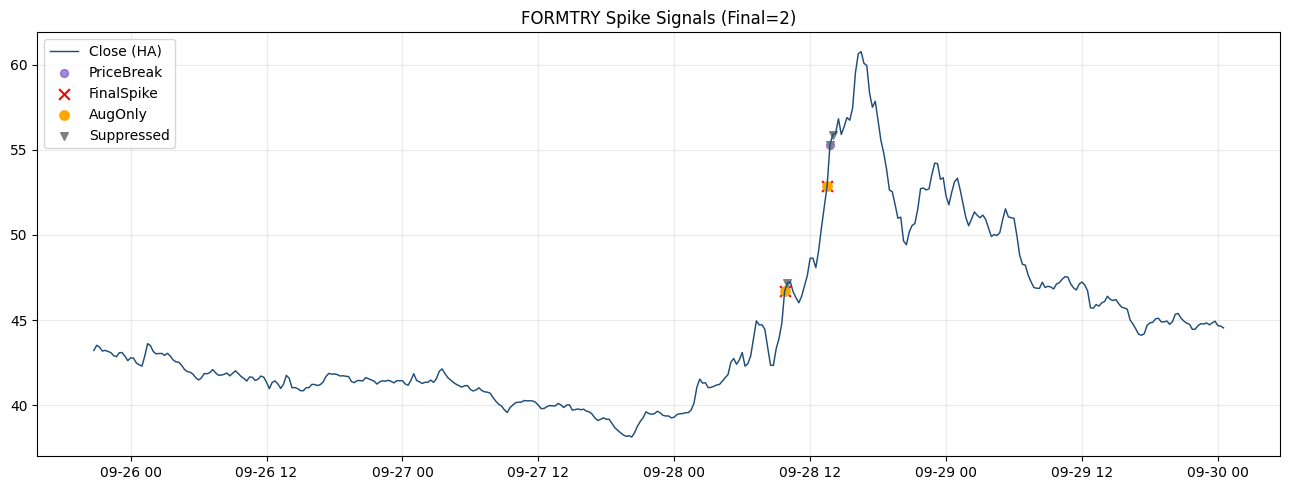

[Production Debug] {'rows': 400, 'volume_cluster_flag': 1, 'price_break_flag': 1, 'base_or': 2, 'base_and': 0, 'chosen': 0, 'after_bull': 0, 'after_body': 0, 'pre': 0, 'aug': 2, 'final': 2, 'suppressed': 3, 'auto_calibrated': True, 'volume_cluster_min_ratio': 3.5480120684874006, 'price_break_base_threshold': 0.045}


{'rows': 400,
 'volume_cluster_flag': 1,
 'price_break_flag': 1,
 'base_or': 2,
 'base_and': 0,
 'chosen': 0,
 'after_bull': 0,
 'after_body': 0,
 'pre': 0,
 'aug': 2,
 'final': 2,
 'suppressed': 3,
 'auto_calibrated': True,
 'volume_cluster_min_ratio': 3.5480120684874006,
 'price_break_base_threshold': 0.045}

In [99]:
import pandas as pd
import numpy as np
import requests
import joblib
from typing import Optional

# Lazy import placeholder for matplotlib (only when plotting)
try:
    import matplotlib.pyplot as plt  # type: ignore

    _MATPLOT_OK = True
except Exception:  # pragma: no cover
    _MATPLOT_OK = False


# ----------------- External Data Fetch Helper ----------------- #
def fetch_binance_klines(
    symbol: str, interval: str = "15m", limit: int = 500, end_time: Optional[int] = None
) -> pd.DataFrame:
    """Fetch klines from Binance REST API and return a standardized DataFrame.
    Columns: timestamp, open, high, low, close, volume, quote_asset_volume, taker_base, taker_quote, number_of_trades
    """
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    if not data:
        raise RuntimeError("Empty response from Binance")
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    num_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_base",
        "taker_quote",
    ]
    df[num_cols] = df[num_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    return (
        df[
            [
                "timestamp",
                "open",
                "high",
                "low",
                "close",
                "volume",
                "quote_asset_volume",
                "taker_base",
                "taker_quote",
                "number_of_trades",
            ]
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


class SpikeHunterV2:  # Production version (snake_case methods) with default Heikin Ashi smoothing + auto-calibration
    REQUIRED_BASE_FEATURES = [
        "price_change",
        "price_change_abs",
        "body_size_pct",
        "upper_wick_ratio",
        "lower_wick_ratio",
        "is_bullish",
        "close_open_ratio",
        "price_zscore",
        "volume_ratio",
        "volume_zscore",
        "momentum_3",
        "momentum_5",
        "range_pct",
        "close_to_high",
        "close_to_low",
        "taker_buy_ratio",
        "trades_ratio",
        "trades_zscore",
        "quote_volume_ratio",
    ]
    EARLY_FEATURES = [
        "std_ratio_8_20",
        "vol_ratio_slope_3",
        "vol_ratio_accel",
        "trades_ratio_slope_3",
        "quote_vol_ratio_slope_3",
        "pc_1",
        "pc_2c",
        "pc_3c",
        "pc_pos_count_5",
        "pc_abs_sum_5",
        "taker_buy_ratio",
        "taker_buy_ratio_slope_5",
        "body_size_pct_z",
        "vol_compression_flag",
        "volume_ratio",
        "price_zscore",
    ]

    def __init__(
        self,
        symbol: str,
        bundle_path: str,
        interval: str = "15m",
        limit: int = 500,
        fetch: bool = True,
        df: Optional[pd.DataFrame] = None,
        auto_calibrate: bool = True,
    ):
        """Initialize production SpikeHunterV2.
        Heikin Ashi smoothing is ALWAYS applied; raw OHLC preserved as raw_*.
        Optionally auto-calibrates volume and price thresholds to the asset's own recent distribution unless bundle locks them.
        Parameters:
            symbol: trading pair symbol (e.g. 'HMSTRTRY')
            bundle_path: path to serialized model bundle
            interval: kline interval (only used if we fetch)
            limit: bars to fetch if fetch=True and df not supplied
            fetch: when True and df is None, will call fetch_binance_klines
            df: optional preloaded DataFrame; if provided, no fetch occurs
            auto_calibrate: when True, derive per-asset thresholds (if not locked) from initial data
        """
        self.symbol = symbol
        self.bundle_path = bundle_path
        self.interval = interval
        self.limit = limit
        self.df: pd.DataFrame = pd.DataFrame()
        self.keep_original_ohlc = True  # always keep raw_* copies
        self.bundle = self.load_bundle(bundle_path)
        self.thresholds = self.bundle.get("thresholds", {})
        self.models = self.bundle.get("models", {})
        # Threshold extraction (names preserved)
        self.volume_cluster_min_ratio = self.thresholds.get(
            "volume_cluster_min_ratio", 2.0
        )
        self.volume_cluster_window = self.thresholds.get("volume_cluster_window", 8)
        self.volume_cluster_min_count = self.thresholds.get(
            "volume_cluster_min_count", 2
        )
        self.volume_cluster_label_mode = self.thresholds.get(
            "volume_cluster_label_mode", "last"
        ).lower()
        self.price_break_base_threshold = self.thresholds.get(
            "price_break_base_threshold", 0.05
        )
        self.price_break_dynamic_q = self.thresholds.get("price_break_dynamic_q", 0.90)
        self.price_break_use_dynamic = self.thresholds.get(
            "price_break_use_dynamic", True
        )
        self.price_break_auto_tune = self.thresholds.get("price_break_auto_tune", False)
        self.price_break_target_rate = self.thresholds.get(
            "price_break_target_rate", 0.02
        )
        self.price_break_min_quantile = self.thresholds.get(
            "price_break_min_quantile", 0.75
        )
        self.price_break_max_quantile = self.thresholds.get(
            "price_break_max_quantile", 0.985
        )
        self.price_break_smoothing = self.thresholds.get("price_break_smoothing", 0.5)
        self.price_break_auto_lookback = self.thresholds.get(
            "price_break_auto_lookback", 180
        )
        self.early_proba_threshold = self.thresholds.get("early_proba_threshold", 0.45)
        self.early_proba_min_slope = self.thresholds.get("early_proba_min_slope", 0.05)
        self.early_proba_require_volume = self.thresholds.get(
            "early_proba_require_volume", 1.0
        )
        self.require_both_patterns = self.thresholds.get("require_both_patterns", False)
        self.post_spike_cooldown_bars = self.thresholds.get(
            "post_spike_cooldown_bars", 0
        )
        self.require_bullish_spike = self.thresholds.get("require_bullish_spike", True)
        self.body_size_pct_min = self.thresholds.get("body_size_pct_min", 0.0)
        self.lock_thresholds = bool(self.thresholds.get("lock_thresholds", False))
        # Models
        self.current_clf = self.models.get("current_classifier")
        self.early_clf = self.models.get("lead_classifier")
        self.early_proba_augment = self.bundle.get("metadata", {}).get(
            "early_proba_augment", True
        )
        self.early_proba_slope_lookback = 3
        self._auto_calibrated = False

        # Data initialization strategy
        if df is not None:
            self.df = df.copy().sort_values("timestamp").reset_index(drop=True)
        elif fetch:
            self.df = fetch_binance_klines(
                self.symbol, interval=self.interval, limit=self.limit
            )
        if not self.df.empty:
            self.df = self.apply_heikin_ashi(self.df)  # Always apply
            # Pre-compute base feats to allow calibration distribution
            self.compute_base_features()
            if auto_calibrate and not self.lock_thresholds:
                self.auto_calibrate()

    @staticmethod
    def apply_heikin_ashi(df: pd.DataFrame) -> pd.DataFrame:
        """
        Exact same function as Binquant project
        keep as is
        """
        if df.empty:
            return df

        required_columns = {"open", "high", "low", "close"}
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"Missing required columns for Heikin Ashi: {missing}")

        # Work on a copy & ensure chronological order if timestamp provided.
        if "timestamp" in df.columns:
            work = df.sort_values("timestamp").reset_index(drop=True).copy()
        else:
            work = df.reset_index(drop=True).copy()

        # Compute HA_Close from ORIGINAL OHLC (still intact in 'work').
        ha_close = (work["open"] + work["high"] + work["low"] + work["close"]) / 4.0

        # Seed HA_Open with original O & C (not HA close).
        ha_open = ha_close.copy()
        ha_open.iloc[0] = (work["open"].iloc[0] + work["close"].iloc[0]) / 2.0
        for i in range(1, len(work)):
            ha_open.iloc[i] = (ha_open.iloc[i - 1] + ha_close.iloc[i - 1]) / 2.0

        # High / Low derived from max/min of (raw high/low, ha_open, ha_close)
        ha_high = pd.concat([work["high"], ha_open, ha_close], axis=1).max(axis=1)
        ha_low = pd.concat([work["low"], ha_open, ha_close], axis=1).min(axis=1)

        # Assign transformed values.
        work.loc[:, "open"] = ha_open
        work.loc[:, "high"] = ha_high
        work.loc[:, "low"] = ha_low
        work.loc[:, "close"] = ha_close

        return work

    # -------------- Auto Calibration -------------- #
    def auto_calibrate(
        self,
        volume_quantile: float = 0.985,
        price_base_floor_quantile: float = 0.80,
        min_volume_ratio: float = 1.3,
        min_price_abs_floor: float = 0.02,
        verbose: bool = True,
    ):
        """Derive per-asset thresholds from recent distribution.
        volume_cluster_min_ratio := max(min_volume_ratio, quantile(volume_ratio, volume_quantile))
        price_break_base_threshold := max(min_price_abs_floor, quantile(price_change_abs, price_base_floor_quantile))
        Only runs once unless manually re-invoked. Skips if insufficient rows (< 60).
        """
        if self._auto_calibrated:
            if verbose:
                print("[AutoCalibrate] Already calibrated; skipping.")
            return
        if len(self.df) < 60:
            if verbose:
                print(
                    "[AutoCalibrate] Not enough data (<60 rows); skipping calibration."
                )
            return
        vols = self.df["volume_ratio"].dropna()
        pcs = self.df["price_change_abs"].dropna()
        if vols.empty or pcs.empty:
            if verbose:
                print("[AutoCalibrate] Missing distribution data; skipping.")
            return
        old_vol_thr = self.volume_cluster_min_ratio
        old_price_floor = self.price_break_base_threshold
        new_vol_thr = float(max(min_volume_ratio, np.quantile(vols, volume_quantile)))
        new_price_floor = float(
            max(min_price_abs_floor, np.quantile(pcs, price_base_floor_quantile))
        )
        self.volume_cluster_min_ratio = new_vol_thr
        # Only raise the base floor upward; don't shrink below bundle-provided base to avoid trivializing rule
        self.price_break_base_threshold = max(old_price_floor, new_price_floor)
        self._auto_calibrated = True
        if verbose:
            print(
                f"[AutoCalibrate] volume_cluster_min_ratio {old_vol_thr:.3f} -> {self.volume_cluster_min_ratio:.3f} (q={volume_quantile})"
            )
            print(
                f"[AutoCalibrate] price_break_base_threshold {old_price_floor:.4f} -> {self.price_break_base_threshold:.4f} (q={price_base_floor_quantile})"
            )
            if self.price_break_use_dynamic:
                print(
                    "[AutoCalibrate] Dynamic price quantile logic will still adapt above calibrated floor."
                )

    # -------------- Bundle -------------- #
    def load_bundle(self, path: str):
        try:
            bundle = joblib.load(path)
            print(f"[LoadBundle] Loaded bundle from {path}")
            return bundle
        except Exception as e:
            raise RuntimeError(f"Failed to load bundle: {e}")

    # -------------- Feature Engineering -------------- #
    def compute_base_features(self, window: int = 12):
        if self.df.empty:
            return
        df = self.df.sort_values("timestamp").reset_index(drop=True).copy()
        eff = window
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
            df["volume"].rolling(eff).std() + 1e-6
        )
        df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
        df["quote_volume_ratio"] = df["quote_asset_volume"] / (
            df["quote_volume_ma"] + 1e-6
        )
        df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
        df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
        df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (
            df["number_of_trades"].rolling(eff).std() + 1e-6
        )
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"] + 1e-6) / (df["close"] + 1e-6)
        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0
        self.df = df

    def compute_early_features(self):
        df = self.df.copy()
        df["rolling_price_std_8"] = df["close"].rolling(8).std()
        df["rolling_price_std_20"] = df["close"].rolling(20).std()
        df["std_ratio_8_20"] = df["rolling_price_std_8"] / (
            df["rolling_price_std_20"] + 1e-6
        )
        df["vol_ratio_slope_3"] = df["volume_ratio"].diff(3)
        df["vol_ratio_accel"] = df["vol_ratio_slope_3"].diff()
        df["trades_ratio_slope_3"] = df.get("trades_ratio", 0).diff(3)
        df["quote_vol_ratio_slope_3"] = df.get("quote_volume_ratio", 0).diff(3)
        df["pc_1"] = df["price_change"]
        df["pc_2c"] = df["price_change"].rolling(2).sum()
        df["pc_3c"] = df["price_change"].rolling(3).sum()
        df["pc_pos_count_5"] = (df["price_change"] > 0).rolling(5).sum()
        df["pc_abs_sum_5"] = df["price_change_abs"].rolling(5).sum()
        df["taker_buy_ratio"] = df.get("taker_buy_ratio", 0.0)
        df["taker_buy_ratio_slope_5"] = df["taker_buy_ratio"].diff(5)
        df["body_size_pct_ma_10"] = df["body_size_pct"].rolling(10).mean()
        df["body_size_pct_std_10"] = df["body_size_pct"].rolling(10).std()
        df["body_size_pct_z"] = (df["body_size_pct"] - df["body_size_pct_ma_10"]) / (
            df["body_size_pct_std_10"] + 1e-6
        )
        df["vol_compression_flag"] = (
            df["rolling_price_std_8"] < df["rolling_price_std_20"] * 0.6
        ).astype(int)
        self.df = df

    # -------------- Rule Components -------------- #
    def volume_cluster_flag(self):
        df = self.df
        cond = df["volume_ratio"] >= self.volume_cluster_min_ratio
        rolling_count = cond.rolling(self.volume_cluster_window, min_periods=1).sum()
        flag = (rolling_count >= self.volume_cluster_min_count) & cond
        if self.volume_cluster_label_mode == "last":
            flag = flag & (~flag.shift(-1).fillna(False))
        self.df["volume_cluster_flag"] = flag.astype(int)

    def price_break_flag(self):
        df = self.df
        if not self.price_break_use_dynamic:
            thr_series = pd.Series(self.price_break_base_threshold, index=df.index)
        else:
            base_dyn = (
                df["price_change_abs"]
                .rolling(60, min_periods=20)
                .quantile(self.price_break_dynamic_q)
            )
            if self.price_break_auto_tune:
                q_recent = 1.0 - self.price_break_target_rate
                q_recent = np.clip(
                    q_recent,
                    self.price_break_min_quantile,
                    self.price_break_max_quantile,
                )
                adaptive = (
                    df["price_change_abs"]
                    .rolling(self.price_break_auto_lookback, min_periods=40)
                    .apply(lambda x: np.quantile(x, q_recent), raw=False)
                )
                dyn = (
                    self.price_break_smoothing * base_dyn
                    + (1 - self.price_break_smoothing) * adaptive
                )
            else:
                dyn = base_dyn
            thr_series = pd.Series(
                np.maximum(self.price_break_base_threshold, dyn), index=df.index
            ).ffill()
        self.df["price_break_flag"] = (df["price_change_abs"] >= thr_series).astype(int)

    def apply_preliminary_label(self):
        self.volume_cluster_flag()
        self.price_break_flag()
        df = self.df
        if self.require_both_patterns:
            label_pre = (
                (df["volume_cluster_flag"] == 1) & (df["price_break_flag"] == 1)
            ).astype(int)
        else:
            label_pre = (
                (df["volume_cluster_flag"] == 1) | (df["price_break_flag"] == 1)
            ).astype(int)
        if self.require_bullish_spike:
            label_pre = label_pre & (df["is_bullish"] == 1)
        if self.body_size_pct_min > 0:
            label_pre = label_pre & (df["body_size_pct"] >= self.body_size_pct_min)
        self.df["label_pre"] = label_pre.astype(int)
        self.df["label"] = self.df["label_pre"].copy()

    def compute_early_proba(self):
        if not self.early_proba_augment or self.early_clf is None:
            self.df["early_spike_proba"] = np.nan
            self.df["early_proba_aug_flag"] = 0
            return
        if any(f not in self.df.columns for f in self.EARLY_FEATURES):
            self.compute_early_features()
        feats = self.df[self.EARLY_FEATURES].fillna(0)
        try:
            proba = self.early_clf.predict_proba(feats)[:, 1]
        except Exception:
            proba = np.zeros(len(self.df))
        self.df["early_spike_proba"] = proba
        slope = self.df["early_spike_proba"] - self.df["early_spike_proba"].shift(
            self.early_proba_slope_lookback
        )
        cond = (
            (self.df["early_spike_proba"] >= self.early_proba_threshold)
            & (slope >= self.early_proba_min_slope)
            & (self.df["volume_ratio"] >= self.early_proba_require_volume)
        )
        if self.require_bullish_spike:
            cond &= self.df["is_bullish"] == 1
        if self.body_size_pct_min > 0:
            cond &= self.df["body_size_pct"] >= self.body_size_pct_min
        self.df["early_proba_aug_flag"] = cond.astype(int)
        self.df["label"] = (
            (self.df["label_pre"] == 1) | (self.df["early_proba_aug_flag"] == 1)
        ).astype(int)

    def apply_cooldown(self):
        if self.post_spike_cooldown_bars <= 0:
            self.df["suppressed_label"] = 0
            return
        last_idx = None
        suppressed = 0
        self.df["suppressed_label"] = 0
        for i in self.df.index:
            if self.df.at[i, "label"] == 1:
                if (
                    last_idx is not None
                    and (i - last_idx) <= self.post_spike_cooldown_bars
                ):
                    self.df.at[i, "suppressed_label"] = 1
                    self.df.at[i, "label"] = 0
                    if (
                        self.df.at[i, "early_proba_aug_flag"] == 1
                        and self.df.at[i, "label_pre"] == 0
                    ):
                        self.df.at[i, "early_proba_aug_flag"] = 0
                    suppressed += 1
                else:
                    last_idx = i
        if suppressed:
            print(f"[Cooldown] Suppressed {suppressed} labels")

    # -------------- Public API -------------- #
    def detect(self) -> pd.DataFrame:
        if self.df.empty:
            raise RuntimeError("No data loaded; set df or call refresh().")
        # Ensure HA & base feats present (idempotent); calibrate if late & allowed
        if "ha_trend_bull" not in self.df.columns:
            self.apply_heikin_ashi(self.df)
        if "volume_ratio" not in self.df.columns:
            self.compute_base_features()
        if not self._auto_calibrated and not self.lock_thresholds:
            self.auto_calibrate(verbose=True)
        # Recompute features (some threshold changes may not require but keep consistent)
        self.compute_base_features()
        self.apply_preliminary_label()
        self.compute_early_proba()
        self.apply_cooldown()
        return self.df

    def refresh(self, limit: Optional[int] = None, recalibrate: bool = False):
        lim = limit or self.limit
        self.df = fetch_binance_klines(self.symbol, interval=self.interval, limit=lim)
        self.apply_heikin_ashi(self.df)
        self.compute_base_features()
        if recalibrate and not self.lock_thresholds:
            self._auto_calibrated = False
            self.auto_calibrate(verbose=True)
        return self.detect()

    def update_with_df(self, new_df: pd.DataFrame, recalibrate: bool = False):
        if self.df.empty:
            self.df = new_df.copy()
        else:
            self.df = (
                pd.concat([self.df, new_df])
                .drop_duplicates("timestamp")
                .sort_values("timestamp")
                .reset_index(drop=True)
            )
        if len(self.df) > 1000:
            self.df = self.df.iloc[-1000:].reset_index(drop=True)
        self.apply_heikin_ashi()
        self.compute_base_features()
        if recalibrate and not self.lock_thresholds:
            self._auto_calibrated = False
            self.auto_calibrate(verbose=True)
        return self.detect()

    def debug_signal_breakdown(self) -> dict:
        needed = {"volume_cluster_flag", "price_break_flag", "label_pre"}
        if not needed.issubset(self.df.columns):
            print("[Debug] Run detect() first.")
            return {}
        d = self.df
        base_or = (
            (d["volume_cluster_flag"] == 1) | (d["price_break_flag"] == 1)
        ).astype(int)
        base_and = (
            (d["volume_cluster_flag"] == 1) & (d["price_break_flag"] == 1)
        ).astype(int)
        chosen = base_and if self.require_both_patterns else base_or
        after_bull = (
            chosen
            if not self.require_bullish_spike
            else (chosen & (d["is_bullish"] == 1)).astype(int)
        )
        after_body = (
            after_bull
            if self.body_size_pct_min <= 0
            else (after_bull & (d["body_size_pct"] >= self.body_size_pct_min)).astype(
                int
            )
        )
        out = {
            "rows": len(d),
            "volume_cluster_flag": int(d["volume_cluster_flag"].sum()),
            "price_break_flag": int(d["price_break_flag"].sum()),
            "base_or": int(base_or.sum()),
            "base_and": int(base_and.sum()),
            "chosen": int(chosen.sum()),
            "after_bull": int(after_bull.sum()),
            "after_body": int(after_body.sum()),
            "pre": int(d["label_pre"].sum()),
            "aug": int(
                d.get("early_proba_aug_flag", pd.Series(0, index=d.index)).sum()
            ),
            "final": int(d["label"].sum()),
            "suppressed": int(
                d.get("suppressed_label", pd.Series(0, index=d.index)).sum()
            ),
            "auto_calibrated": self._auto_calibrated,
            "volume_cluster_min_ratio": self.volume_cluster_min_ratio,
            "price_break_base_threshold": self.price_break_base_threshold,
        }
        print("[Production Debug]", out)
        return out

    def latest_signal(self, run_detect: bool = False) -> dict:
        """Return classification of the most recent bar.
        Parameters:
            run_detect: when True, force a fresh detect() pass before reading.
        Returns:
            dict with keys:
                timestamp, close, label, label_pre, early_proba_aug_flag,
                is_final_spike, is_aug_only, is_suppressed, signal_type
        """
        if self.df.empty:
            raise RuntimeError("No data available.")
        if run_detect or "label" not in self.df.columns:
            self.detect()
        row = self.df.iloc[-1]
        is_final = bool(row.get("label", 0) == 1)
        is_aug_only = bool(
            is_final
            and row.get("label_pre", 0) == 0
            and row.get("early_proba_aug_flag", 0) == 1
        )
        is_supp = bool(row.get("suppressed_label", 0) == 1)
        if is_final:
            signal_type = "AugOnly" if is_aug_only else "FinalSpike"
        elif is_supp:
            signal_type = "Suppressed"
        else:
            signal_type = "None"
        return {
            "timestamp": row.get("timestamp"),
            "close": float(row.get("close", np.nan)),
            "label": int(row.get("label", 0)),
            "label_pre": int(row.get("label_pre", 0)),
            "early_proba_aug_flag": int(row.get("early_proba_aug_flag", 0)),
            "is_final_spike": is_final,
            "is_aug_only": is_aug_only,
            "is_suppressed": is_supp,
            "signal_type": signal_type,
        }

    # -------------- Simple Plot -------------- #
    def plot_signals(
        self,
        show_aug: bool = True,
        show_suppressed: bool = False,
        show_price_break: bool = True,
    ):
        """Quick single-panel visualization of price with spike markers.
        Parameters:
            show_aug: show augmentation-only (orange) markers.
            show_suppressed: show suppressed (cooldown) markers in gray.
            show_price_break: show price_break_flag bars (purple dots) regardless of final label.
        """
        if not _MATPLOT_OK:
            raise ImportError(
                "matplotlib not available. Install matplotlib to use plot_signals()."
            )
        if "label" not in self.df.columns:
            self.detect()
        df = self.df
        plt.figure(figsize=(13, 5))
        plt.plot(
            df["timestamp"],
            df["close"],
            label="Close (HA)",
            linewidth=1.05,
            color="#1f4e79",
        )
        # Price break markers (before final spikes so spikes overlay)
        if show_price_break and "price_break_flag" in df.columns:
            pb_idx = df.index[df["price_break_flag"] == 1]
            if len(pb_idx) > 0:
                plt.scatter(
                    df.loc[pb_idx, "timestamp"],
                    df.loc[pb_idx, "close"],
                    c="#7e57c2",
                    s=32,
                    marker="o",
                    alpha=0.7,
                    label="PriceBreak",
                )
        final_idx = df.index[df["label"] == 1]
        if len(final_idx) > 0:
            plt.scatter(
                df.loc[final_idx, "timestamp"],
                df.loc[final_idx, "close"],
                c="red",
                marker="x",
                s=60,
                label="FinalSpike",
            )
        if show_aug and "early_proba_aug_flag" in df.columns:
            aug_only_idx = df.index[
                (df["early_proba_aug_flag"] == 1)
                & (df["label_pre"] == 0)
                & (df["label"] == 1)
            ]
            if len(aug_only_idx) > 0:
                plt.scatter(
                    df.loc[aug_only_idx, "timestamp"],
                    df.loc[aug_only_idx, "close"],
                    c="orange",
                    s=45,
                    label="AugOnly",
                )
        if show_suppressed and "suppressed_label" in df.columns:
            sup_idx = df.index[df["suppressed_label"] == 1]
            if len(sup_idx) > 0:
                plt.scatter(
                    df.loc[sup_idx, "timestamp"],
                    df.loc[sup_idx, "close"],
                    c="gray",
                    s=30,
                    marker="v",
                    label="Suppressed",
                )
        plt.title(f"{self.symbol} Spike Signals (Final={int(df['label'].sum())})")
        plt.legend(loc="upper left")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


# Example usage (always active, using HMSTRTRY with default Heikin Ashi smoothing & auto calibration)
raw_df = fetch_binance_klines("FORMTRY", interval="15m", limit=400)
prod = SpikeHunterV2(
    symbol="FORMTRY",
    bundle_path="../checkpoints/spikehunter_model_v2.pkl",
    df=raw_df,
    fetch=False,
    auto_calibrate=True,
)
prod.detect()
print(prod.latest_signal())
prod.plot_signals(show_aug=True, show_suppressed=True, show_price_break=True)
prod.debug_signal_breakdown()